# Notebook para la Función `find_similar`

Este notebook demuestra cómo utilizar la función `find_similar` para identificar trayectorias similares en un conjunto de datos GeoJSON. 
La función hace uso de la biblioteca `stmeasures`, que proporciona herramientas avanzadas para calcular distancias espaciales y temporales entre trayectorias mediante algoritmos como:

### ¿Qué hace la función `find_similar`?
1. **Entrada**:
   - Una trayectoria pivote (`pivot_trajectory`) que actúa como referencia.
   - Un conjunto de datos en formato GeoJSON (`geojson_dataset`) que contiene múltiples trayectorias.
   - Un valor opcional de sigma (`sigma`) para filtrar trayectorias basadas en la distancia máxima permitida.
   - Un algoritmo (Frechet o Hausdorff) para calcular las distancias.
2. **Proceso**:
   - Calcula la distancia entre la trayectoria pivote y cada trayectoria en el conjunto de datos utilizando el algoritmo especificado.
   - Si se proporciona `sigma`, filtra trayectorias cuya distancia exceda este valor.
3. **Salida**:
   - Un diccionario ordenado con los índices de las trayectorias similares y sus distancias respectivas.


In [ ]:
import json
import stmeasures
import utils
import warnings
import geojsonio

: 

## Cargar Archivos y Preparar Datos

In [ ]:
# Cargar los datos
g_ecatepec = stmeasures.read_file('ECATEPEC.json')
g_similar = utils.read_file('map.geojson')
g_similar_u = utils.read_file('u.geojson')

# Preparar datos de prueba
value_pivot = 251
pivot_trajectory = [value_pivot]
geojson_dataset = utils.get_all_trajectories(g_ecatepec, 0, 5000)

## Implementación de la Función `find_similar`

In [ ]:
from typing import List, Optional, Dict

def find_similar(
    pivot_trajectory: List[List[tuple[float, float]]],
    geojson_dataset: stmeasures.GeoJSON,
    sigma: Optional[float] = None,
    algorithm=stmeasures.Algorithms.FRECHET
) -> Dict[int, float]:
    """
    Encuentra trayectorias similares en un conjunto de datos GeoJSON.

    Args:
        pivot_trajectory (List[List[tuple[float, float]]]): La trayectoria pivote.
        geojson_dataset (stmeasures.GeoJSON): Conjunto de datos en formato GeoJSON.
        sigma (Optional[float]): Umbral para filtrar distancias mayores (opcional).
        algorithm: Algoritmo a utilizar (Frechet o Hausdorff).

    Returns:
        Dict[int, float]: Diccionario con índices y distancias de trayectorias similares.
    """
    similar_trajectories = {}
    
    for idx, trajectory in enumerate(geojson_dataset):
        distance = stmeasures.distance(pivot_trajectory, trajectory, algorithm)
        if sigma is None or distance <= sigma:
            similar_trajectories[idx + 1] = distance
    
    return dict(sorted(similar_trajectories.items(), key=lambda item: item[1]))

## Ejecutar la Función con Parámetros de Ejemplo

In [ ]:
ts = find_similar(
    *utils.get_trajectories(g_ecatepec, pivot_trajectory), 
    geojson_dataset, 
    sigma=0.0067, 
    algorithm=stmeasures.Algorithms.HAUSDORFF
)

keys = list(ts.keys())
keys.append(value_pivot)


In [ ]:
print("***************************")
geojsonio.display(stmeasures.geojsonio_contents(trajectories=[*utils.get_trajectories(g_ecatepec, keys)]))
print(ts)


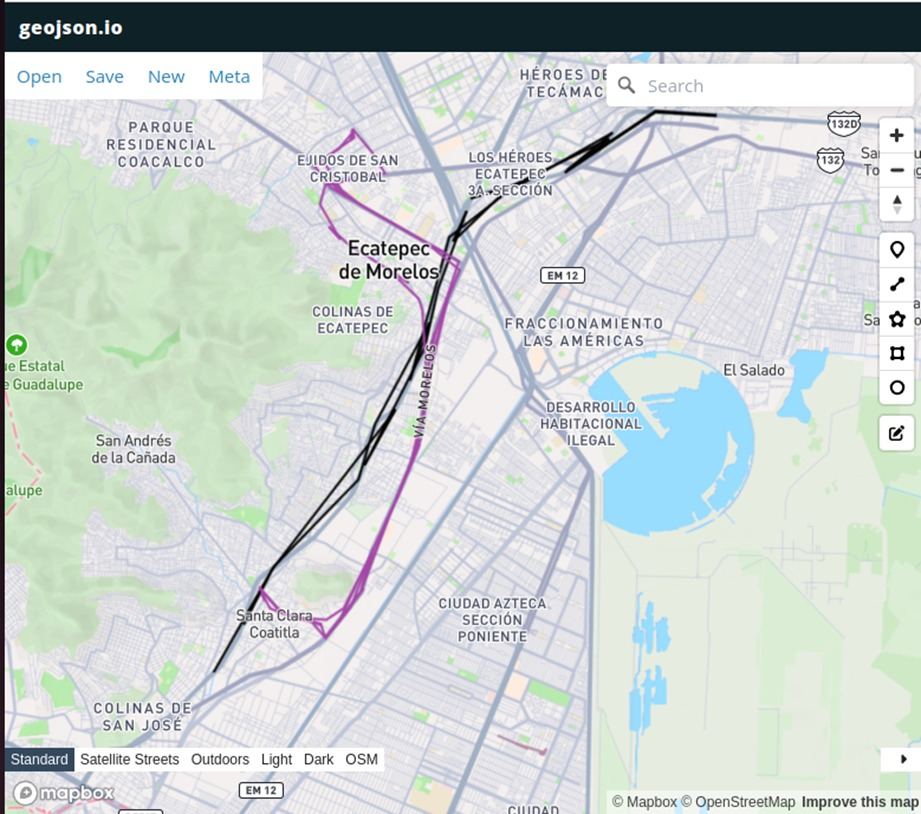